## FlipKart Laptop Sales Under 70,000

Name: Sudesh Kumar Guntur

GH Number:GH1047585

Module Name : M512B Data Visualisation and Communication

Data set link: https://www.kaggle.com/datasets/rajkumarpandey02/best-flipkart-laptop-under-70000

Source Link: https://www.flipkart.com/laptops/~laptops-under-rs70000/pr?sid=6bo%2Cb5g&page

Git Hub link:

# BUSSINESS PROBLEM

THE flipkart is facing the problem to filter best laptops according to to its price,RAM,and storage and how they can tell their  coustomers about the performance of the laptops and and also filter most commonly used proseccor laptops . And which are the top 5 laptops highly rated under 70k with highest rating and also used for basic to median use laptops.

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [18]:
import warnings
warnings.filterwarnings('ignore')  

In [7]:
df=pd.read_csv(r"C:\Users\Sudes\Downloads\Flipkart laptops_info (1).csv", on_bad_lines='skip')

In [8]:
df

,ProductName,Stars,Ratings,Reviews,Current_Price,MRP,Proccessor,Ram,Storage,ImageURL
0,Lenovo IdeaPad 3 Core i3 10th Gen,4.3,8,0,31990,53790,Intel Core i3 Processor (10th Gen),4 GB DDR4 RAM,256 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
1,realme Book(Slim) Intel Evo Core i5 11th Gen,4.4,7067,949,59990,69999,Powered by 11th Gen Intel Evo Core i5 Processor,Microsoft Office 2019 Home & Student Included,Intel Core i5 Processor (11th Gen),https://rukminim1.flixcart.com/image/312/312/k...
2,ASUS VivoBook 15 (2022) Core i3 10th Gen,4.3,9970,999,32990,45990,Intel Core i3 Processor (10th Gen),8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
3,HP Pavilion Ryzen 5 Hexa Core AMD R5,4.4,11854,1199,52990,63539,AMD Ryzen 5 Hexa Core Processor,8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...
4,Lenovo Intel Celeron Dual Core,4.1,366,35,28490,40490,Intel Celeron Dual Core Processor,8 GB DDR4 RAM,256 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...
...,...,...,...,...,...,...,...,...,...,...
676,Infinix INBook X2 Plus Core i3 11th Gen,4.1,146,32,40990,49990,Intel Core i3 Processor (11th Gen),8 GB LPDDR4X RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
677,DELL Inspiron Ryzen 3 Dual Core 3250U,4.5,4,0,40790,50132,AMD Ryzen 3 Dual Core Processor,8 GB DDR4 RAM,256 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...
678,MSI Core i3 12th Gen,0.0,0,0,45490,58990,Intel Core i3 Processor (12th Gen),8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
679,ASUS Core i3 10th Gen,4.7,12,0,33990,45499,Intel Core i3 Processor (10th Gen),8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...


In [5]:
df.head()

,ProductName,Stars,Ratings,Reviews,Current_Price,MRP,Proccessor,Ram,Storage,ImageURL
0,Lenovo IdeaPad 3 Core i3 10th Gen,4.3,8,0,31990,53790,Intel Core i3 Processor (10th Gen),4 GB DDR4 RAM,256 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
1,realme Book(Slim) Intel Evo Core i5 11th Gen,4.4,7067,949,59990,69999,Powered by 11th Gen Intel Evo Core i5 Processor,Microsoft Office 2019 Home & Student Included,Intel Core i5 Processor (11th Gen),https://rukminim1.flixcart.com/image/312/312/k...
2,ASUS VivoBook 15 (2022) Core i3 10th Gen,4.3,9970,999,32990,45990,Intel Core i3 Processor (10th Gen),8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
3,HP Pavilion Ryzen 5 Hexa Core AMD R5,4.4,11854,1199,52990,63539,AMD Ryzen 5 Hexa Core Processor,8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...
4,Lenovo Intel Celeron Dual Core,4.1,366,35,28490,40490,Intel Celeron Dual Core Processor,8 GB DDR4 RAM,256 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...


In [7]:
df.dtypes

ProductName       object
Stars            float64
Ratings            int64
Reviews            int64
Current_Price      int64
MRP                int64
Proccessor        object
Ram               object
Storage           object
ImageURL          object
dtype: object

In [8]:
df.shape

(681, 10)

## Checking Duplicates

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(576, 10)

In [12]:
df.columns

Index(['ProductName', 'Stars', 'Ratings', 'Reviews', 'Current_Price', 'MRP',
       'Proccessor', 'Ram', 'Storage', 'ImageURL'],
      dtype='object')

## Checking Missing Values

In [13]:
df.isnull().sum()

ProductName      0
Stars            0
Ratings          0
Reviews          0
Current_Price    0
MRP              0
Proccessor       0
Ram              0
Storage          0
ImageURL         0
dtype: int64

In [129]:
## Data Cleaning 

In [134]:
df['Ram'].unique()

array(['4 GB DDR4 RAM', 'Microsoft Office 2019 Home & Student Included',
       '8 GB DDR4 RAM', '16 GB DDR4 RAM',
       'RAM & Storage: 8GB DDR4 & 1TB HDD + 256GB SSD', '4 GB LPDDR4 RAM',
       '4 GB LPDDR4X RAM', 'RAM & Storage: 8GB DDR4 & 1TB + 256GB SSD',
       'RAM & Storage: 8GB DDR4 (2 DIMM Slots) & 256GB SSD',
       'RAM & Storage: 8GB DDR4 & 512GB SSD',
       'AMD Ryzen 5 Hexa Core Processor', '8 GB LPDDR4X RAM',
       'RAM & Storage: 8GB DDR4 & 256GB SSD', '16 GB LPDDR4X RAM',
       'RAM & Storage: 8GB DDR4 (2 DIMM Slots) & 1TB HDD',
       'RAM & Storage: 8GB DDR4 (2 DIMM Slots) & 512GB SSD',
       'NVIDIA Geforce GTX 1050 for Desktop Level Performance',
       '8 GB DDR3 RAM', 'Intel Core i5 Processor (11th Gen)',
       'Intel Core i7 Processor (7th Gen)', '8 GB DDR5 RAM',
       '16 GB LPDDR5 RAM',
       'Preloaded Microsoft Office Home and Student 2016',
       '64 GB DDR4 RAM', '4 GB DDR3 RAM'], dtype=object)

In [135]:
df['RAM_Clean'] = df['Ram'].str.extract(r'(\d+)\s*GB')[0]
df['RAM_Clean'] = df['RAM_Clean'].astype(float)

In [136]:
df['ROM_Clean'] = df['Storage'].str.extract(r'(\d+)\s*GB')[0]
df['ROM_Clean'] = df['ROM_Clean'].astype(float)
df = df.dropna(subset=['ROM_Clean'])

In [14]:
import missingno 

<Axes: >

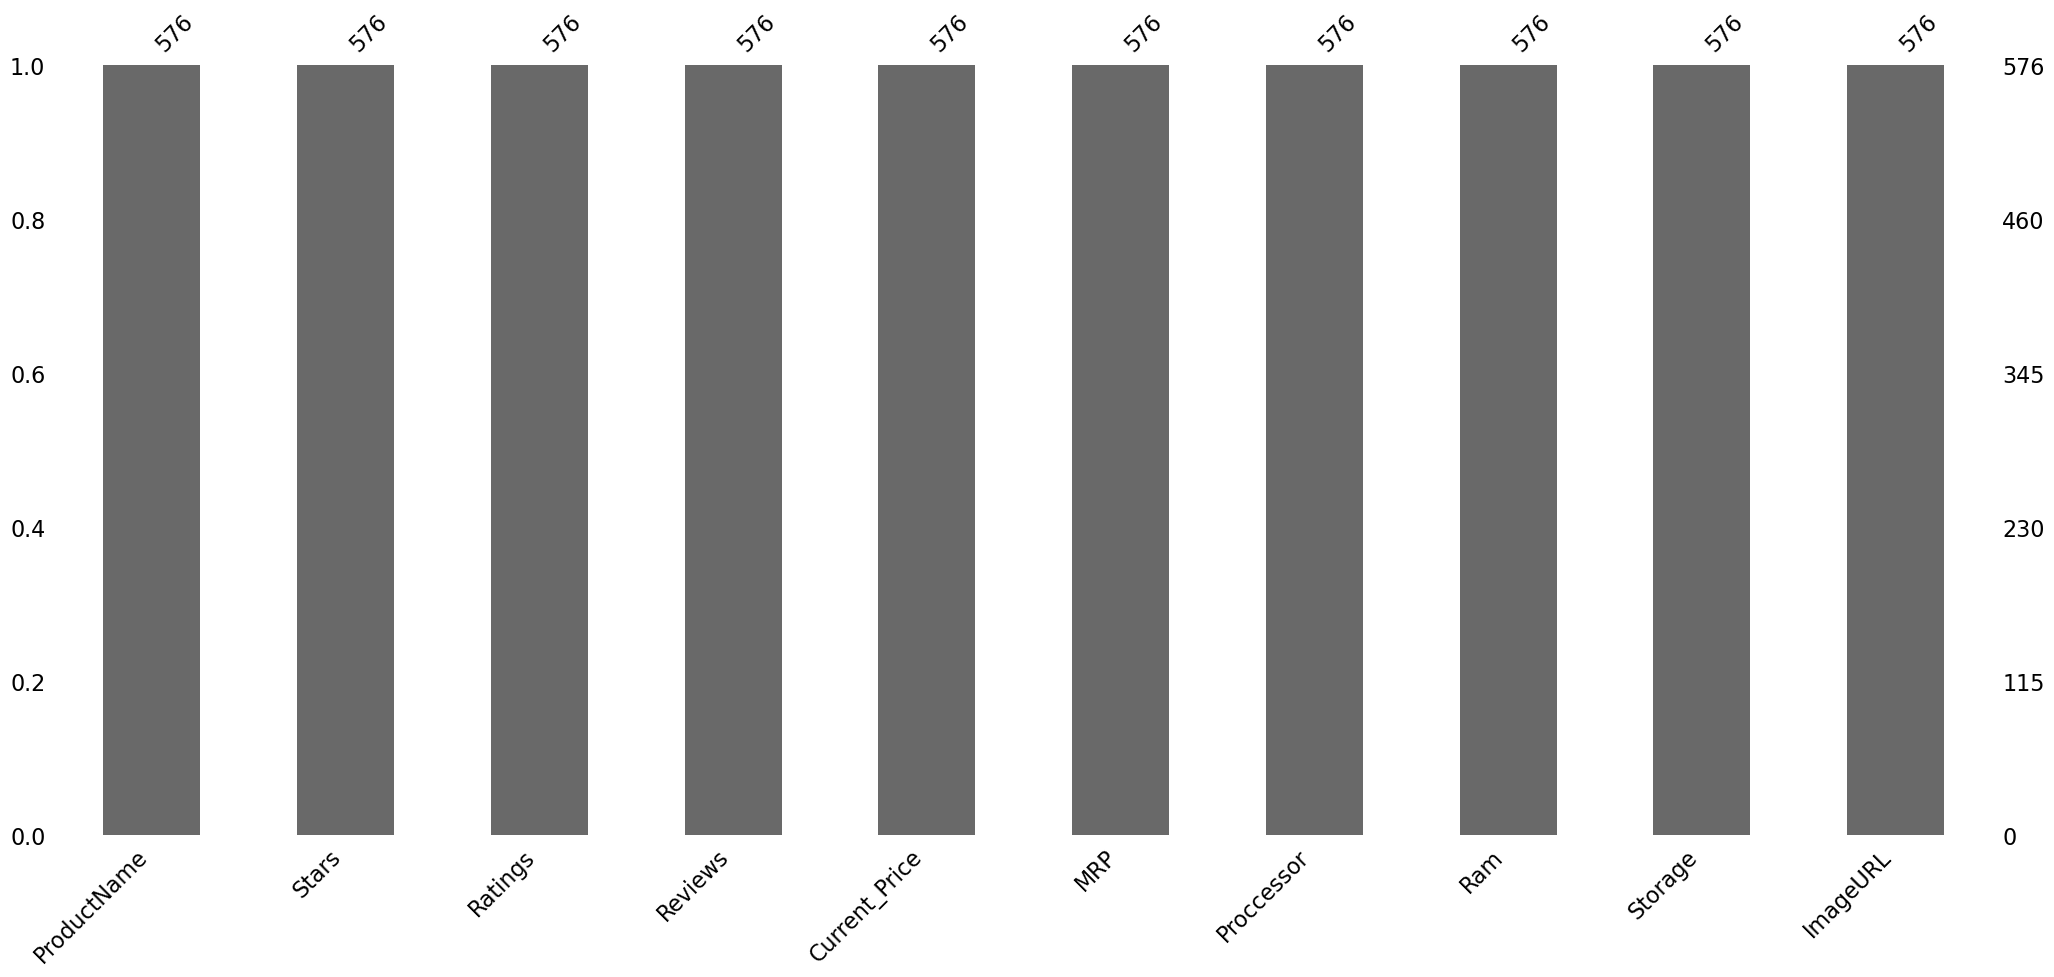

In [15]:
missingno.bar(df)

In [16]:
df.describe()

,Stars,Ratings,Reviews,Current_Price,MRP
count,576.000000,576.000000,576.000000,576.000000,576.000000
mean,3.389931,600.907986,72.539931,48032.821181,62033.975694
std,1.629501,1494.784290,179.547339,14068.137839,20101.331347
min,0.000000,0.000000,0.000000,15990.000000,0.000000
25%,3.600000,8.000000,1.000000,37965.000000,48967.500000
50%,4.100000,85.500000,10.000000,47060.000000,60430.500000
75%,4.300000,451.500000,56.500000,59990.000000,76915.000000
max,5.000000,17745.000000,2300.000000,102000.000000,136990.000000


In [17]:
df

,ProductName,Stars,Ratings,Reviews,Current_Price,MRP,Proccessor,Ram,Storage,ImageURL
0,Lenovo IdeaPad 3 Core i3 10th Gen,4.3,8,0,31990,53790,Intel Core i3 Processor (10th Gen),4 GB DDR4 RAM,256 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
1,realme Book(Slim) Intel Evo Core i5 11th Gen,4.4,7067,949,59990,69999,Powered by 11th Gen Intel Evo Core i5 Processor,Microsoft Office 2019 Home & Student Included,Intel Core i5 Processor (11th Gen),https://rukminim1.flixcart.com/image/312/312/k...
2,ASUS VivoBook 15 (2022) Core i3 10th Gen,4.3,9970,999,32990,45990,Intel Core i3 Processor (10th Gen),8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
3,HP Pavilion Ryzen 5 Hexa Core AMD R5,4.4,11854,1199,52990,63539,AMD Ryzen 5 Hexa Core Processor,8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...
4,Lenovo Intel Celeron Dual Core,4.1,366,35,28490,40490,Intel Celeron Dual Core Processor,8 GB DDR4 RAM,256 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...
...,...,...,...,...,...,...,...,...,...,...
676,Infinix INBook X2 Plus Core i3 11th Gen,4.1,146,32,40990,49990,Intel Core i3 Processor (11th Gen),8 GB LPDDR4X RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
677,DELL Inspiron Ryzen 3 Dual Core 3250U,4.5,4,0,40790,50132,AMD Ryzen 3 Dual Core Processor,8 GB DDR4 RAM,256 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...
678,MSI Core i3 12th Gen,0.0,0,0,45490,58990,Intel Core i3 Processor (12th Gen),8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/x...
679,ASUS Core i3 10th Gen,4.7,12,0,33990,45499,Intel Core i3 Processor (10th Gen),8 GB DDR4 RAM,512 GB SSD,https://rukminim1.flixcart.com/image/312/312/k...


# WHAT IS THE DISTRIBUTION OF LAPTOP PRICES ?

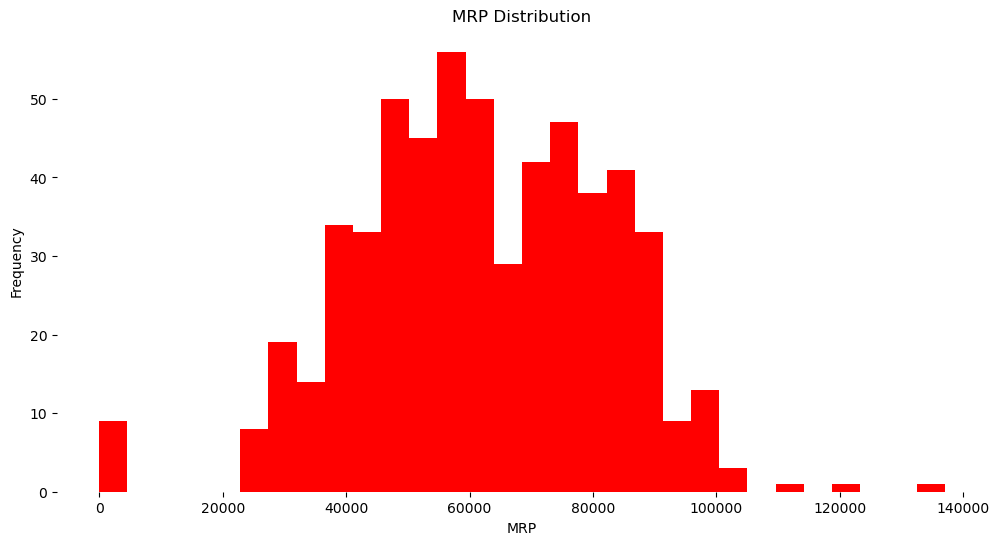

In [70]:
plt.figure(figsize=(12,6))
plt.hist(df['MRP'],color='red', bins=30)
plt.title("MRP Distribution")
plt.xlabel("MRP")
plt.ylabel("Frequency")
plt.box(False)
plt.show()

This histogram shows MRP distributions of laptop we have taken x-axis as MRP and y-axis as freqency here the starting price of the laptops start 25,000 
which are very basic laptop and the highest range of laptop goes up 1,30,000 most laptops sale at median range of price about 40,000 to 80,000 range and
there only few laptops which are sold at the price at 1,00,000 and goes upto 1,30,000 which are high-end laptops the large number of laptops distributed at the MRP of 55,000 at and the frequency of 50 and above

# WHAT ARE MOST RATED TOP 5 LAPTOPS ?

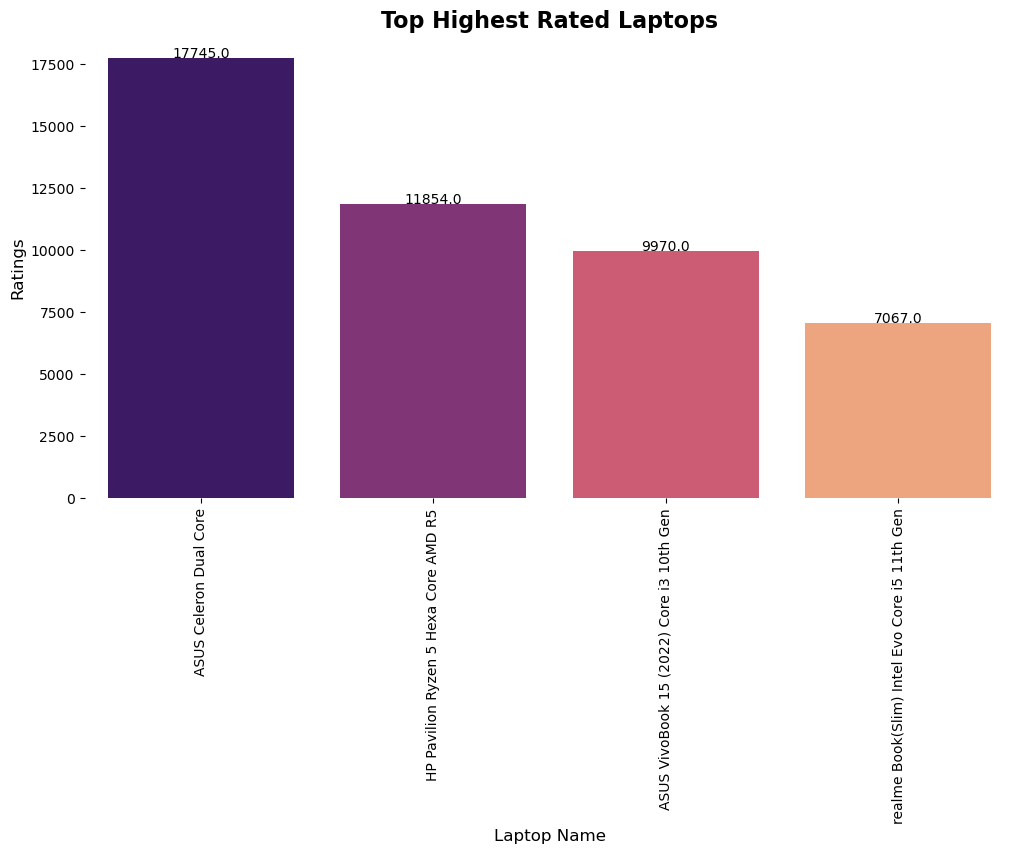

In [19]:
top5 = df.sort_values(by="Ratings", ascending=False).head()
plt.figure(figsize=(12,6))
ax = sns.barplot(x=top5['ProductName'], y=top5['Ratings'], palette='magma')
plt.title("Top Highest Rated Laptops", fontsize=16, weight='bold')
plt.xlabel('Laptop Name', fontsize=12)
plt.ylabel('Ratings', fontsize=12)
plt.xticks(rotation=45)
bars = ax.patches
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.05,
             f"{yval:.1f}",
             ha='center')
             
plt.box(False)
plt.xticks(rotation=90)
plt.show()

This barplot show  4 high rated laptops names and ratings for the laptops firstly we have x-axis as laptop name and the y-axis as ratings for the laptops the and ratings starts from 0 and goes up to 17500 top 1  laptop is ASUS celeron dual core which has a highest rating of 17745.0 and next is laptop is HP Pavilion Ryzen 5 Hexa core AMD R5 with a rating of 11854.0 and this stands at 2nd place.The next laptop is ASUS VIVOBook 15 (2022) core i3 10th gen stands at 3rd with rating of 9970.0 the 4th laptop is realme Book(slim) intel evo core i5 11th Gen has rating of  7067.0 . In flipkart this laptops high ratings not only because of the price each laptop has a very standard where it comes the components like processor,Ram,storage and working conditions of the laptop and also great durability and also can also be great choice for coders which help in coding complex versions without any discomfort from pc

# WHAT ARE THE MOST AFFORDABLE LATOPS AND WHAT ARE THE PRICES OF THE LAPTOPS ?

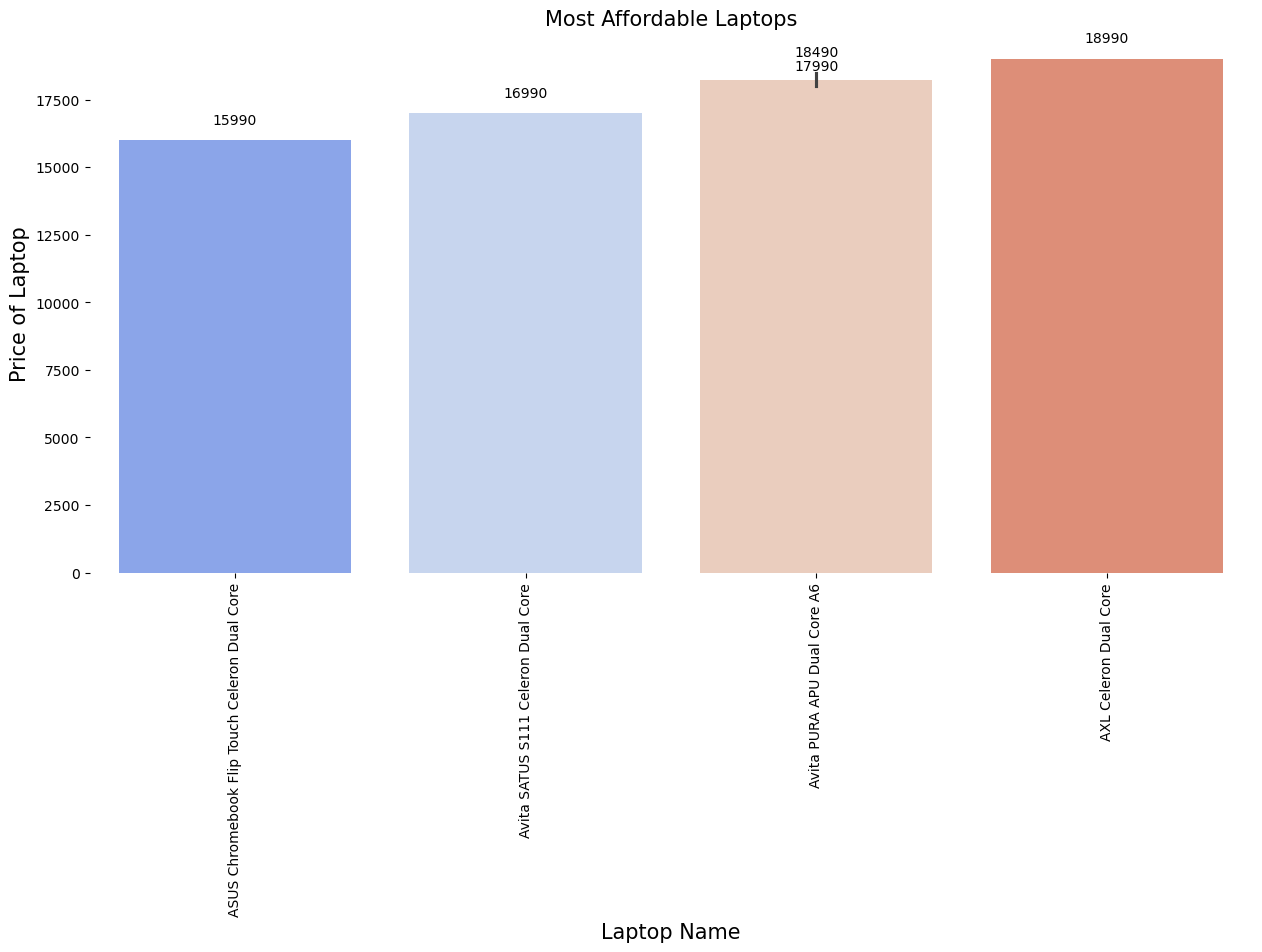

In [73]:
top5 = df.sort_values(by="Current_Price", ascending=True).head()

plt.figure(figsize=(15,7))
sns.barplot(x=top5['ProductName'],y=top5['Current_Price'],palette='coolwarm')

plt.title("Most Affordable Laptops", fontsize=15)
plt.xlabel("Laptop Name", fontsize=15)
plt.ylabel("Price of Laptop", fontsize=15)
plt.xticks(rotation=90)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 500,  
             f"{int(yval)}",
             ha='center', va='bottom', fontsize=10)
plt.box(False)
plt.show()

In this barplot we show what the most affordable laptops and prices of the laptops we start with x-axis and y-axis we named x axis as laptop name and y-axis as price of the laptops the most afforable laptop is ASUS Chromebook Touch celeron Dual core with the price of 15,990 and next laptop name is Avita SATUS S111 Celeron Dual core with the price of 16,990 the 3rd laptop is Avita OURA APU DUAL CORE A6 this laptop price varies becuase of the ram because this laptop comes models of 4GB and 8GB RAM the price range of this laptop is 17,990 which is 4GB RAM and other one is 18,490 which is 8GB RAM the last laptop is AXL Celeron Dual core the price of this laptop is 18,990 this 4 laptops are the most affordable laptops this laptops give maximum performace minimal and affordable price where if see all the companies may not able afford high-end laptops for this would be the better option this laptops provide basic mean features and good ram and storage which can be good option for work related purpose

In [77]:
df['Ram'].unique()

array(['4 GB DDR4 RAM', 'Microsoft Office 2019 Home & Student Included',
       '8 GB DDR4 RAM', '16 GB DDR4 RAM',
       'RAM & Storage: 8GB DDR4 & 1TB HDD + 256GB SSD', '4 GB LPDDR4 RAM',
       '4 GB LPDDR4X RAM', 'RAM & Storage: 8GB DDR4 & 1TB + 256GB SSD',
       'RAM & Storage: 8GB DDR4 (2 DIMM Slots) & 256GB SSD',
       'RAM & Storage: 8GB DDR4 & 512GB SSD',
       'AMD Ryzen 5 Hexa Core Processor', '8 GB LPDDR4X RAM',
       'RAM & Storage: 8GB DDR4 & 256GB SSD', '16 GB LPDDR4X RAM',
       'RAM & Storage: 8GB DDR4 (2 DIMM Slots) & 1TB HDD',
       'RAM & Storage: 8GB DDR4 (2 DIMM Slots) & 512GB SSD',
       'NVIDIA Geforce GTX 1050 for Desktop Level Performance',
       '8 GB DDR3 RAM', 'Intel Core i5 Processor (11th Gen)',
       'Intel Core i7 Processor (7th Gen)', '8 GB DDR5 RAM',
       '16 GB LPDDR5 RAM',
       'Preloaded Microsoft Office Home and Student 2016',
       '64 GB DDR4 RAM', '4 GB DDR3 RAM'], dtype=object)

In [79]:
df['RAM_Clean'] = df['Ram'].str.extract(r'(\d+)\s*GB')[0]
df['RAM_Clean'] = df['RAM_Clean'].astype(float)

In [80]:
df['RAM_Clean'].unique()

array([ 4., nan,  8., 16., 64.])

In [81]:
df = df.dropna(subset=['RAM_Clean'])

# WHAT IS THE PRICE DIFFRENCE BETWEEN 4GB RAM AND 16GB RAM ?

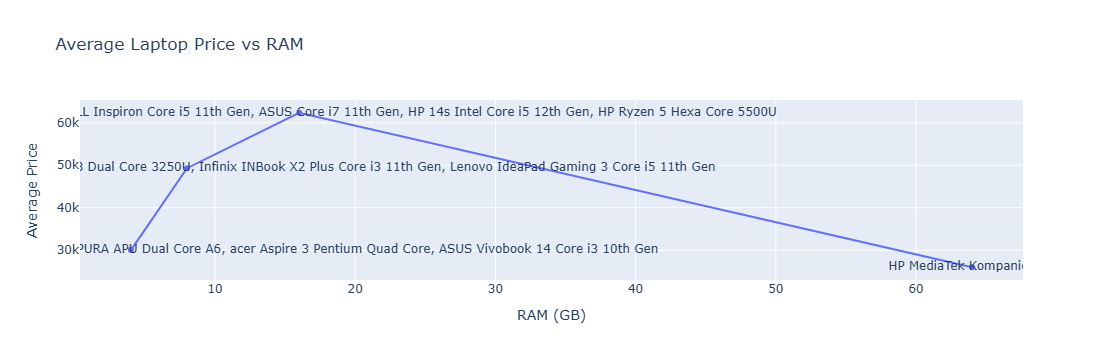

In [100]:
import plotly.express as px

# Group data (average price per RAM)
ram_price = df.groupby('RAM_Clean', as_index=False).agg({
    'Current_Price': 'mean',
    'ProductName': lambda x: ', '.join(x.head(5))  
})
fig = px.line(
    ram_price,
    x='RAM_Clean',
    y='Current_Price',
    markers=True,
    text='ProductName',   
    title='Average Laptop Price vs RAM',
    labels={
        'RAM_Clean': 'RAM (GB)',
        'Current_Price': 'Average Price'
    }
)
fig.show()

Here the price diffrence between 4GM RAM 16GB RAM the price of 4GB RAM 30.04291K and price of the 16GB ram is 62.36876k approximately the price range between these two laptops is 30k thsi happens because the RAM has very strong impact on laptops pricing the 4GB ram laptops cheap and basic laptops which are used typing  and browsing purposes and also for students who can work assingmesnts and studies can also used by working professionals for basic work related purposes for 8GB TO 16GB RAM the price shoots up because of more RAM 49k to 62k the 16GB ram laptops can be considered powerfull mid range laptops good preocessprs and chip for better performance  where as we can see there is laptop with average price 25.999k with RAM of 64GB we can assume that why do have a lot of when we can get 64GB ram for basic price 26k but the problem with these kind laptops use  low-quality processors for ex- hp media tek gives lots of RAM but with weaker chip the RAM cannot be purposefull without a proper processor

In [105]:
# Extract storage in GB (handles SSD/HDD etc.)
df['ROM_Clean'] = df['Storage'].str.extract(r'(\d+)\s*GB')[0]

# Convert to numeric
df['ROM_Clean'] = df['ROM_Clean'].astype(float)

# Remove invalid rows
df = df.dropna(subset=['ROM_Clean'])

# WHICH RAM SIZE HAS THE MOST NUMBER OF LAPTOPS  ? 

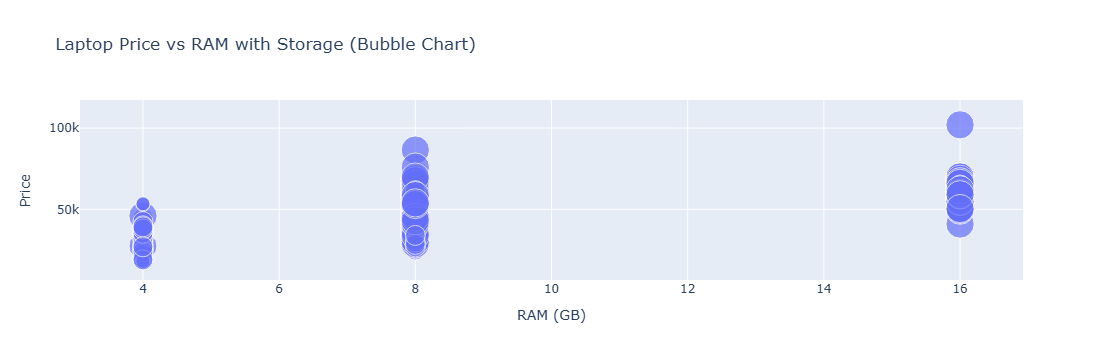

In [108]:
import plotly.express as px

fig = px.scatter(
    df,
    x='RAM_Clean',
    y='Current_Price',
    size='ROM_Clean',         
    hover_name='ProductName',  
    title='Laptop Price vs RAM with Storage (Bubble Chart)',
    labels={
        'RAM_Clean': 'RAM (GB)',
        'Current_Price': 'Price',
        'ROM_Final': 'Storage (GB)'
    }
)

fig.show()

The RAM size with more number of laptops is 8 because the between 4GB and 16GB ram 8 is acts as median regarding feartures and performance wise and price value to student or working professional this laptops have price range of 24k to highest of 86k where its not so cheap but at the same time not too expensive becuase some have less storage and some have more storage according to the price and also in this segment we more options in laptops compared to other 2 segments the laptops with 8GB RAM have good speeed also have affordable price can also handle basic to mediuam tasks other two segments which are 4GB and 16G GB prices range (17k to 53k) for 4GB and (40k to 1.2k) for 16GB 8GB is a most balanced choice for daily users. The price is not only decided on basis of RAM but also the storage so the RAM and storage decide the final price of the laptop 

In [117]:
high = df.nlargest(5, 'MRP')
low = df.nsmallest(5, 'MRP')
final_df = pd.concat([high, low])

# WHAT IS HIGHEST AND LOWEST PRICE OF THE LAPTOP ?

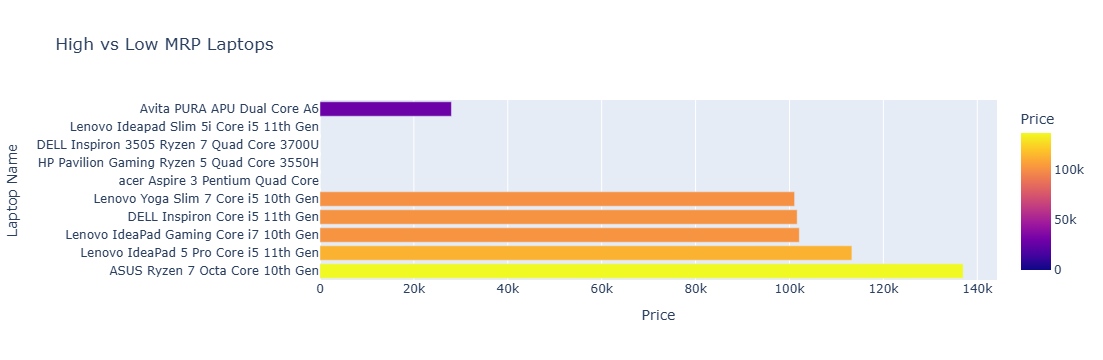

In [118]:
import plotly.express as px

fig = px.bar(
    final_df,
    x='MRP',
    y='ProductName',
    color='MRP',   # gives gradient effect
    orientation='h',
    title='High vs Low MRP Laptops',
    labels={
        'MRP': 'Price',
        'ProductName': 'Laptop Name'
    }
)

fig.show()

THE HIGH AND LOW PRICES OF THE LAPTOPS ARE AVITA PURA APU DUAL CORE A6 with lowest price of 27990 and ASUS ryzen 7 Octa Core 1oth Gen is highest priced laptop with price range of 136990 DEll inspironslim 5i core i5 11th gen,DELL inspiron 3505 Ryzen 7 quad core 3700u, HP Pavilion gaming ryzen 5 quad core 35505H this 3 laptops are budget freindly laptops the the total price range shows 0 to 100k the other four laptops prices ranges are premium mid-range laptops cost around 1,00,000k to 1,10,000k the processor type matters a lot for price

# HOW MANY PROCESSORS ARE SHOWN IN THIS CHART ?

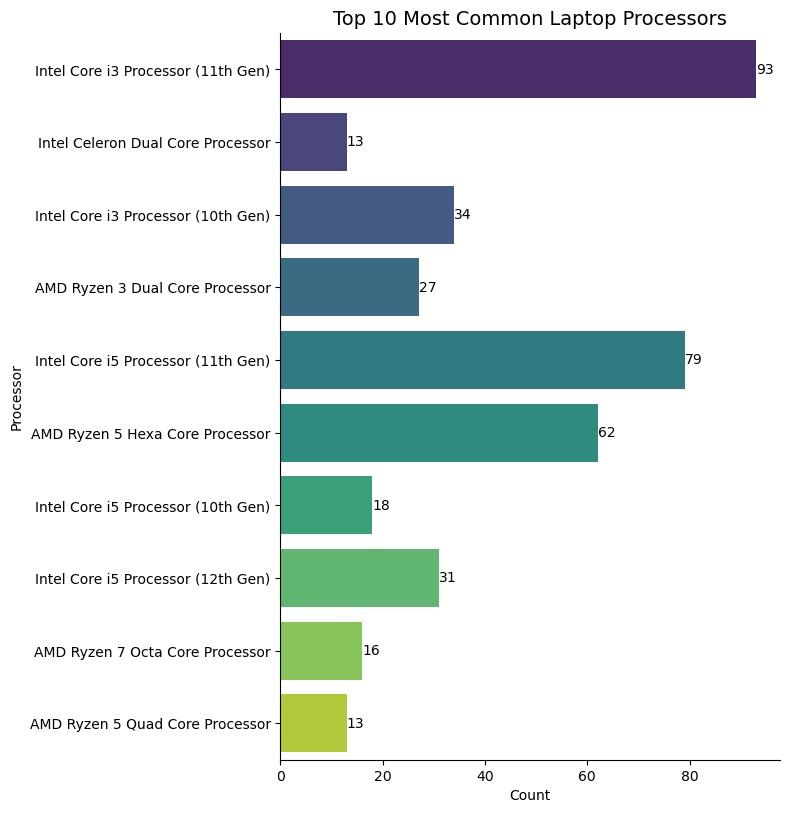

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

top_proc = df['Proccessor'].value_counts().head(10).index
df_filtered = df[df['Proccessor'].isin(top_proc)]

g = sns.catplot(
    data=df_filtered,
    y='Proccessor',
    kind='count',
    height=8,
    palette='viridis'   
)

ax = g.ax
for container in ax.containers:
    ax.bar_label(container)

ax.set_title('Top 10 Most Common Laptop Processors', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Processor')

plt.show()

The number of  processors shown  in this chart are 6 intel and 4 AMD processors are shown in this chart where with count of 0 to 8 the top 10 most common processors are Intel Core i3 Processor (11th Gen) with count of 93 laptops with highest and AMD ryzen 5 quad core processor with count of 13 laptops with low count the intel dominates the markent with 6 out of 10 processors while AMD has only 4 i5 11th GEN and i3 11th gen are the are choosen mostly because they match perfectly to the every day laptop users and working professionals 

# RECOMMENDATIONS

SMART FILTERING SYSTEM FOR PRICE , RAM AND STORAGE 
FILPKART SHOULD MAINLY FOCUS ON THE 8GB RAM 512GB STORAGE LAPTOPS FOR BEST VALUE WHICH COST AROUND 40 TO 80 K

In [ ]:
COMUNICATE THE PERFORMANCE TO THE CUSTOMER 
THE COSTUMER SOULD UNDERSTAND THE PERFORMANCE OF THE LAPTOP ABOUT STORAGE, RAM, PROCESSOR SHOULD TELL THE DIFFRECENCE BETWEEN THE BASIC USE AND DAVANCED USE AND PERFORMENCES 

Highlighting Most Commonly Used Processor Laptop
Intel Core i5 11th Gen and Intel Core i3 11th Gen  are the most used processor for laptops so we sould highligt this will help buyers to identify more quikly,

The top 5 laptops under 70k 
ASUS VivoBook 15 Core i3 10th Gen, HP Pavilion Ryzen 5 Hexa Core, Lenovo IdeaPad Slim Core i5 11th Gen,DELL Inspiron Core i5 11th Gen,
Realme Book Slim Core i5 11th Gen this laptops offer the value for money and performance


# CONCLUSION

The flipkart sales show that 40 to 70k with 8GB RAM are most preferable by the customers intel dominates i3 and i5 generations being the popular and laptops 512 Gb are mostly used to solve this problem flipkart has to create dedicated section for top rated and most popular processors laptops flipkart can reduce the confusion by increasing the laptop sales by across all segments